In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import copy

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.model.cnn_simple import CIFAR10ReLU
from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
from common.optimise_v4 import NetLineStepProcessor

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 64 #128 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0, reduction='mean')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [6]:
def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_ADAM['test_loss'], color='g', alpha=.5, label='Adam')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Net-line')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='SGD')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_ADAM['test_accuracy'], color='g', alpha=.5, label='Adam')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Net-line')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='SGD')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same CNN architecture for different optimisers")

    plt.show()

#### Reference CNN

In [7]:
def make_model(dropout_const = 1.0):
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5*dropout_const),
        nn.Linear(256, 10)
    )

    return model


In [8]:
'''
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), 
              nn.BatchNorm2d(out_channels), 
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True) 
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128)) 
        
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True) 
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512)) 
        self.conv5 = conv_block(512, 1028, pool=True) 
        self.res3 = nn.Sequential(conv_block(1028, 1028), conv_block(1028, 1028))  
        
        self.classifier = nn.Sequential(nn.MaxPool2d(2), # 1028 x 1 x 1
                                        nn.Flatten(), # 1028 
                                        nn.Linear(1028, num_classes)) # 1028 -> 100
        
    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.conv5(out)
        out = self.res3(out) + out
        out = self.classifier(out)
        return out

def make_model():
    model = ResNet9(3, OUTPUT_DIM)
    return model
'''

'\ndef conv_block(in_channels, out_channels, pool=False):\n    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), \n              nn.BatchNorm2d(out_channels), \n              nn.ReLU(inplace=True)]\n    if pool: layers.append(nn.MaxPool2d(2))\n    return nn.Sequential(*layers)\n\nclass ResNet9(nn.Module):\n    def __init__(self, in_channels, num_classes):\n        super().__init__()\n        \n        self.conv1 = conv_block(in_channels, 64)\n        self.conv2 = conv_block(64, 128, pool=True) \n        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128)) \n        \n        self.conv3 = conv_block(128, 256, pool=True)\n        self.conv4 = conv_block(256, 512, pool=True) \n        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512)) \n        self.conv5 = conv_block(512, 1028, pool=True) \n        self.res3 = nn.Sequential(conv_block(1028, 1028), conv_block(1028, 1028))  \n        \n        self.classifier = nn.Sequential(nn.Ma

In [ ]:
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)
HISTORY_ADAM = collections.defaultdict(list)

: 

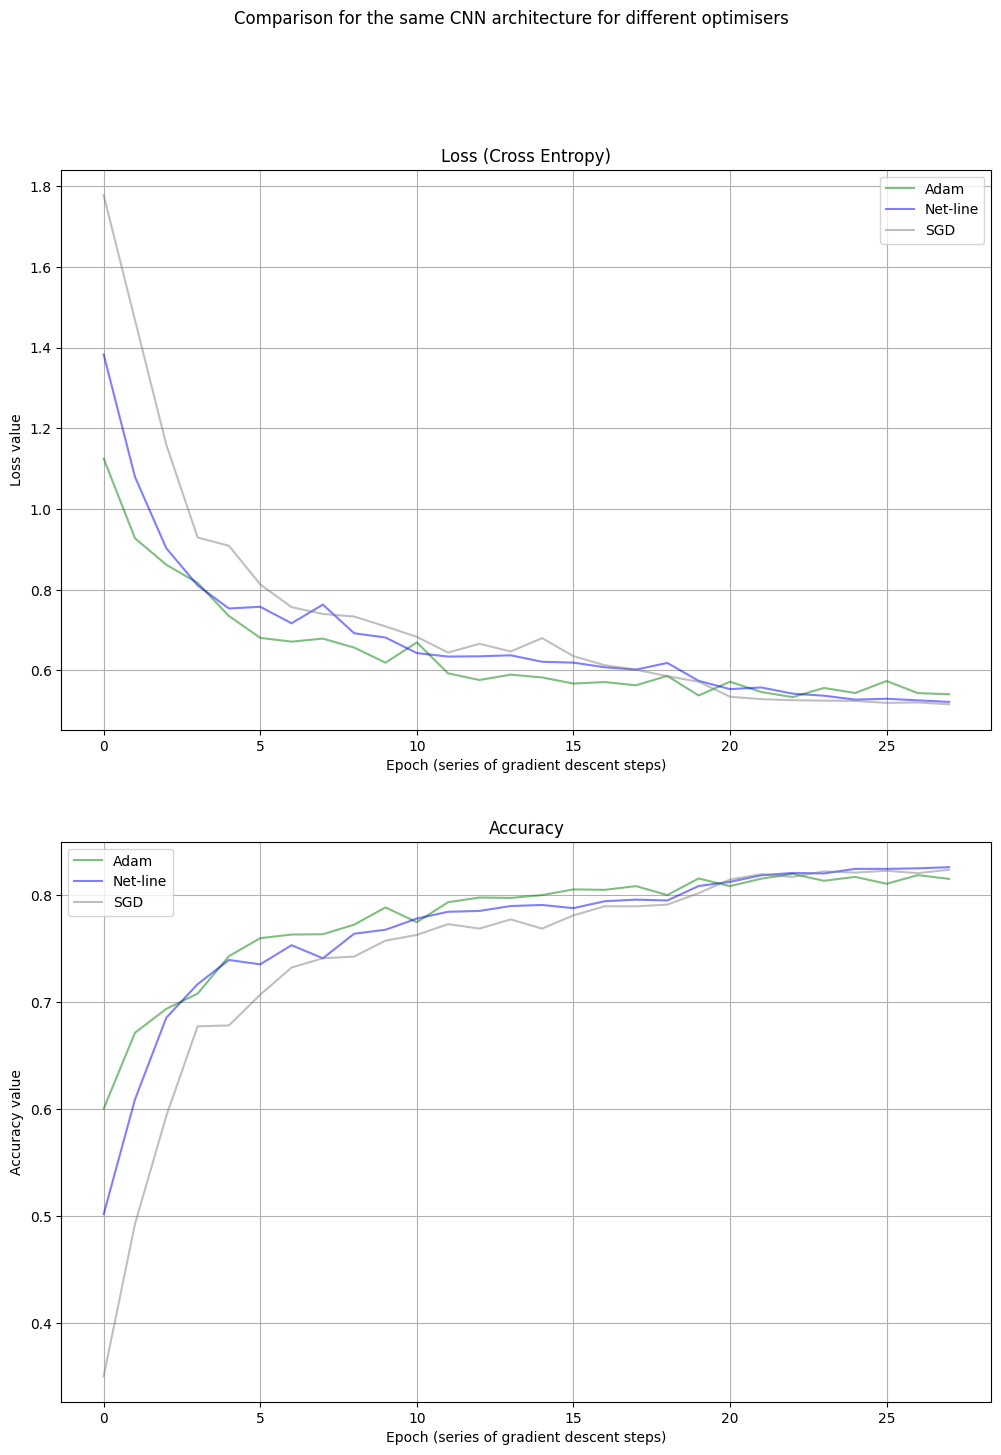

accuracy norm2=[0.501890923566879, 0.6091759554140127, 0.685609076433121, 0.7169585987261147, 0.7395501592356688, 0.73546974522293, 0.7533837579617835, 0.7411425159235668, 0.7641321656050956, 0.7678144904458599, 0.7782643312101911, 0.7846337579617835, 0.7854299363057324, 0.7900079617834395, 0.7910031847133758, 0.7880175159235668, 0.7944864649681529, 0.7959792993630573, 0.7951831210191083, 0.808718152866242, 0.8125995222929936, 0.8187699044585988, 0.8209593949044586, 0.8204617834394905, 0.8247412420382165, 0.8247412420382165, 0.8252388535031847, 0.8263335987261147], 
eta ratio norm2=[9.326087677161695, 9.918289914002719, 11.058118064712277, 10.963948408257048, 10.931042128521211, 10.98759503482196, 10.915665815628227, 11.061214530522195, 11.141932897822166, 11.091913403542527, 11.057493985041871, 11.036419266106483, 11.051258067078148, 10.973748136250089, 10.955227265238273, 10.9903604875185, 10.943591679748147, 10.94328688727832, 10.913634022600458, 9.919570167284324, 8.57874569364679,

In [ ]:
def test_loop(testNet):
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    return test_loss_meter.avg, test_accuracy_meter.avg

NUM_EPOCH = 50
eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

testAdam = copy.deepcopy(testOptfix)
loss_adam = nn.CrossEntropyLoss()
optimizerAdam = optim.Adam(testAdam.parameters()) #, lr=eta_fixed, weight_decay =0.001

training_mode, epoch_switch=True, 100
beta_coeff = 0.1
for epoch in range(NUM_EPOCH):
    threshold = 10. if epoch < 20 else 2.5
    loss_data, ratio_data = HISTORY_NORM2['test_loss'], HISTORY_NORM2['eta_ratio']
    if (len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < -0.01) or (len(ratio_data) > 0 and ratio_data[-1]<threshold):
        beta_coeff = beta_coeff * 2.0
    #    training_mode = True
    epoch_switch = min(epoch, epoch_switch) if training_mode else epoch_switch

    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.0000000049
    stepProcessor.eta_max = 1.0 #if not do_dropout else lr
    #stepProcessor.alpha = 1.0 #1.0/BATCH_SIZE if not training_mode else 1.0/(2.0*BATCH_SIZE) \
        #if epoch < 10 else 1.0/(4.0*BATCH_SIZE) if epoch < 20 else 1.0/(8.0*BATCH_SIZE)    
    #stepProcessor.reducing_coeff = 1.0/BATCH_SIZE if not training_mode else 1.0/(4.0*BATCH_SIZE) \
    #    if epoch < 10 else 1.0/(16.0*BATCH_SIZE) if epoch < 20 else 1.0/(64.0*BATCH_SIZE)
    stepProcessor.eta_min = 0.000001 #if not do_dropout else lr
    stepProcessor.eta0 = 0.0001 #0.000_000_1 #0.000_000_25 #0.000_000_25-no-dropout #0.000_000_5
    stepProcessor.alpha = 1.0 #0.5
    stepProcessor.beta = beta_coeff
    stepProcessor.iter_max = 2
    stepProcessor.momentum_gradient_smoothing_coefficient = 0.0 #10.0 #10.0
    stepProcessor.training_mode=training_mode
    testNorm2S.train(False)

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train(True)

    #optimizerAdam.param_groups[0]['lr'] = lr
    testAdam.train(True)    

    train_eta2raw_plus_meter, train_eta2raw_minus_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter, train_etaratio_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    iter=0
    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True)
        train_eta2_meter.update(step_result.eta)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)
        train_etaratio_meter.update(step_result.eta_ratio)
        if step_result.eta_raw > 0.0:
            train_eta2raw_plus_meter.update(step_result.eta_raw)
        else:
            train_eta2raw_minus_meter.update(step_result.eta_raw)        

        logging.info("####Step with SGD-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

        logging.info("####Step with Adam-fix, eta={}".format(optimizerAdam.param_groups[0]['lr']))
        logitsAdam = testAdam.forward(images)
        lossAdam = loss_adam(logitsAdam, labels)
        optimizerAdam.zero_grad()
        lossAdam.backward()
        optimizerAdam.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw_plus'].append(train_eta2raw_plus_meter.avg)
    HISTORY_NORM2['train_eta_raw_minus'].append(train_eta2raw_minus_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)
    HISTORY_NORM2['eta_ratio'].append(train_etaratio_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    testAdam.eval()
    # testing loop
    netl, neta = test_loop(testNorm2S)
    HISTORY_NORM2['test_loss'].append(netl)
    HISTORY_NORM2['test_accuracy'].append(neta) 

    sgdl, sgda = test_loop(testOptfix)
    HISTORY_OPTFIX['test_loss'].append(sgdl)
    HISTORY_OPTFIX['test_accuracy'].append(sgda)

    adaml, adama = test_loop(testAdam)
    HISTORY_ADAM['test_loss'].append(adaml)
    HISTORY_ADAM['test_accuracy'].append(adama)    
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM)
    print("accuracy norm2={}, \neta ratio norm2={}, \naccuracy sgd-fix={}, \naccuracy adam-fix={}, \nswitch={}, beta={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_NORM2['eta_ratio'], HISTORY_OPTFIX['test_accuracy'], HISTORY_ADAM['test_accuracy']\
                  , epoch_switch, stepProcessor.beta))


In [1]:
HISTORY_NORM2['train_eta']

NameError: name 'HISTORY_NORM2' is not defined

In [12]:
HISTORY_NORM2['train_eta_raw_plus']

[0.026544748869423287,
 0.03322901467488509,
 0.03373297424001456,
 0.03319390150204287,
 0.03278399841693693,
 0.032369108009006976,
 0.02280088093931598,
 0.022836567252976274,
 0.0227148788108215,
 0.022477715294844935,
 0.015805741518611707,
 0.01579606146565682,
 0.01566803095529099,
 0.010953487956079273,
 0.010931158830405789,
 0.007655153885238182,
 0.007587615609588252,
 0.007581246233008055,
 0.007561530535254184,
 0.007526161309932175,
 0.00525660291683886,
 0.005244746758560255,
 0.0036784002609598935,
 0.003653232909132291,
 0.003653352768540221,
 0.003638629614787119,
 0.0036511626738958193,
 0.0025410375340047466,
 0.002541068491974753,
 0.0025416596295322553,
 0.002531498228942305,
 0.0025207312597884312,
 0.00178367281058764,
 0.0017665993964000254,
 0.0012447796306823522,
 0.0012397339290387763,
 0.0012303350143560057,
 0.0008750258653835259,
 0.0008740452631773859,
 0.0008724097154599454,
 0.000870268753673069,
 0.0008639222606194361,
 0.0008733416175694063,
 0.00086

In [13]:
HISTORY_NORM2['train_eta_raw_minus']

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 -3.619159263102497e-05,
 0,
 0,
 0]

In [14]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.46884952229299365, 0.6060907643312102, 0.6585390127388535, 0.6960589171974523, 0.7127786624203821, 0.7163614649681529, 0.7342754777070064, 0.7513933121019108, 0.7630374203821656, 0.7584593949044586, 0.7722929936305732, 0.7889132165605095, 0.7806528662420382, 0.799562101910828, 0.7962778662420382, 0.8039410828025477, 0.8141918789808917, 0.8111066878980892, 0.8118033439490446, 0.8075238853503185, 0.8159832802547771, 0.8122014331210191, 0.8174761146496815, 0.8238455414012739, 0.8205613057324841, 0.8221536624203821, 0.8196656050955414, 0.8210589171974523, 0.8223527070063694, 0.8237460191082803, 0.8277269108280255, 0.8231488853503185, 0.8268312101910829, 0.82703025477707, 0.8266321656050956, 0.8302149681528662, 0.8273288216560509, 0.8302149681528662, 0.8295183121019108, 0.8295183121019108, 0.8297173566878981, 0.8287221337579618, 0.8310111464968153, 0.830015923566879, 0.8305135350318471, 0.832703025477707, 0.8309116242038217, 0.8322054140127388, 0.8299164012738853, 0.830911